# 19. Chimera COSMOS + DR7Q Weighted Photometry

For each row in `chimera_provenance.csv`, this notebook reads the matched COSMOS2015 object and DR7Q quasar photometry, converts DR7Q AB magnitudes to microJy, and computes

`F = F_cosmos + w * F_qso`

for the `u`, `r`, `i`, and `z` bands, where `w` is `chimera_qso_weight`.

## Milky Way Extinction Correction

Before adding the COSMOS galaxy flux and weighted DR7Q quasar flux, this notebook first applies the COSMOS source-filter preprocessing used by `gal/convert_gal.py`, then converts the COSMOS galaxy-side optical bands into SDSS-like bands. The COSMOS-to-SDSS conversion follows the same model-offset idea as `data/chimeras-2023-10-11/convertphotsys.py`, but it does **not** read Chimera's prebuilt `input-gal_converted.fits`: it starts from `COSMOS2015_Laigle+_v1.1.fits` and requires the independent model-offset grid `GALOI15PP_SED.fits`.

For each COSMOS object and band, the notebook matches the model-offset grid by `MODEL`, rounded galaxy redshift, `EXTINCTION`, and `AGE`. It then applies `m_sdss = m_source + (m_sdss_model - m_source_model)` where the source filter is `CFHT_u` for `u`, and `SUBARU_r`, `SUBARU_i`, `SUBARU_z` for `r`, `i`, `z`. The corrected SDSS-like galaxy flux is then used in the flux addition.

For the COSMOS galaxy component, the source-filter preprocessing uses the `EBV` column and the source-filter coefficients from `gal/filternames.txt`: `CFHT_u=4.660`, `SUBARU_r=2.660`, `SUBARU_i=1.991`, and `SUBARU_z=1.461`. This is applied before the SDSS model-offset conversion. The DR7Q photometry table used here does not contain an `E(B-V)` column, but it does contain `AU`, the catalogued extinction in the SDSS `u` band. I therefore infer the DR7Q color excess as `E(B-V) = AU / R_u`, then apply the SDSS band-by-band correction to the DR7Q fluxes.

The SDSS coefficients used for the DR7Q component are `R_u=4.239`, `R_r=2.285`, `R_i=1.698`, and `R_z=1.263`. The weighted flux columns below use the source-preprocessed, SDSS-converted COSMOS galaxy flux and the dereddened DR7Q QSO flux; raw and intermediate component fluxes are retained in separate columns for auditing.

## COSMOS to SDSS Filter Conversion Process

The goal of this notebook is to rebuild the Chimera-style hybrid photometry from the original input catalogs, rather than using Chimera's already-built intermediate products. For that reason, the addition step does **not** read `input-gal_converted.fits` or use its `u_sdss/r_sdss/i_sdss/z_sdss` columns. Instead, it starts from `COSMOS2015_Laigle+_v1.1.fits` and applies the same kind of model-based filter conversion that Chimera used upstream.

The COSMOS optical bands are not exactly SDSS filters. The notebook maps the observed COSMOS-side filters as follows: `u` starts from `u_FLUX_APER3` and is treated as the observed `CFHT_u` band; `r` starts from `r_FLUX_APER3` and is treated as `SUBARU_r`; `i` starts from `ip_FLUX_APER3` and is treated as `SUBARU_i`; `z` starts from `zpp_FLUX_APER3` and is treated as `SUBARU_z`.

Before the SDSS model-offset conversion, each source-filter flux is preprocessed in the same spirit as `gal/convert_gal.py`: invalid fluxes, negative-error measurements, zero fluxes, and nonzero band flags are marked invalid, and the source-filter foreground extinction factor from `gal/filternames.txt` is applied. This step is performed directly from the raw COSMOS columns, not from `gal/input.fits`.

For each COSMOS object, the notebook looks up a matching row in an external model-offset grid, expected first at `data/chimeras-2023-10-11/GALOI15PP_SED.fits` and also accepted at `data/GALOI15PP_SED.fits`. The lookup key is the COSMOS `MODEL`, the Chimera/object redshift rounded to 0.1, the COSMOS `EXTINCTION`, and the COSMOS `AGE`. Once a model row is found, the notebook computes a band-specific magnitude offset:

`delta_mag = model_sdss_mag - model_source_filter_mag`

and applies it to the observed COSMOS magnitude:

`observed_sdss_mag = observed_source_mag + delta_mag`

That converted magnitude is then transformed back into microJy and used as the galaxy-side flux in the hybrid sum. This is a synthetic photometric-system conversion: it estimates what the galaxy flux would have been through an SDSS-like filter, given the best-fitting galaxy SED model.

Important reproducibility note: `GALOI15PP_SED.fits` is not a Chimera output table like `input-gal_converted.fits`; it is the independent model grid needed to reproduce the conversion from the raw COSMOS catalog. If that file is missing, the notebook intentionally raises an error instead of silently falling back to unconverted COSMOS fluxes.

In [21]:
from pathlib import Path
import csv
import os

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp") / "matplotlib"))

import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.table import Table

In [22]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()

PROVENANCE_CSV = PROJECT_ROOT / "chimera_provenance.csv"
COSMOS_FITS = PROJECT_ROOT / "data" / "COSMOS2015_Laigle+_v1.1.fits"
DR7Q_FITS = PROJECT_ROOT / "data" / "dr7q_photometry" / "dr7qso.fit"
CHIMERA_PHOT_FITS = PROJECT_ROOT / "data" / "chimeras-2023-10-11" / "chimeras-grahsp.fits"
CHIMERA_FULLINFO_FITS = PROJECT_ROOT / "data" / "chimeras-2023-10-11" / "chimeras-fullinfo.fits"
MODEL_OFFSET_CANDIDATES = [
    PROJECT_ROOT / "data" / "chimeras-2023-10-11" / "GALOI15PP_SED.fits",
    PROJECT_ROOT / "data" / "GALOI15PP_SED.fits",
]
MODEL_OFFSET_FITS = next((path for path in MODEL_OFFSET_CANDIDATES if path.exists()), MODEL_OFFSET_CANDIDATES[0])
OUTPUT_CSV = PROJECT_ROOT / "notebook_outputs" / "19_chimera_cosmos_dr7q_weighted_photometry.csv"
DEVIATIONS_CSV = PROJECT_ROOT / "notebook_outputs" / "19_chimera_cosmos_dr7q_photometry_deviations.csv"
DEVIATION_PLOT = PROJECT_ROOT / "notebook_outputs" / "19_chimera_cosmos_dr7q_deviation_summary.png"

# COSMOS2015 has aperture fluxes in microJy. APER3 is the default here;
# change COSMOS_APERTURE to "APER2" if you want the smaller aperture instead.
COSMOS_APERTURE = "APER3"

MW_EXTINCTION_COEFFICIENTS = {
    "u": 4.239,
    "r": 2.285,
    "i": 1.698,
    "z": 1.263,
}

# Source-filter foreground-extinction factors used by gal/convert_gal.py.
SOURCE_FILTER_EBV_COEFFICIENTS = {
    "u": 4.660,  # CFHT_u
    "r": 2.660,  # SUBARU_r
    "i": 1.991,  # SUBARU_i / ip
    "z": 1.461,  # SUBARU_z / zpp
}

BAND_COLUMNS = {
    "u": {"cosmos_flux": f"u_FLUX_{COSMOS_APERTURE}", "dr7q_mag": "UMAG", "source_model_band": "CFHT_u"},
    "r": {"cosmos_flux": f"r_FLUX_{COSMOS_APERTURE}", "dr7q_mag": "RMAG", "source_model_band": "SUBARU_r"},
    # COSMOS2015 names these broad bands ip and zp.
    "i": {"cosmos_flux": f"ip_FLUX_{COSMOS_APERTURE}", "dr7q_mag": "IMAG", "source_model_band": "SUBARU_i"},
    "z": {"cosmos_flux": f"zpp_FLUX_{COSMOS_APERTURE}", "dr7q_mag": "ZMAG", "source_model_band": "SUBARU_z"},
}

In [23]:
AB_ZEROPOINT_MICROJY = 3631e6


def text_value(value):
    """Return a clean Python string for FITS byte/string fields."""
    if isinstance(value, bytes):
        return value.decode("utf-8").strip()
    return str(value).strip()


def ab_mag_to_microjy(mag):
    """Convert AB magnitude to flux density in microJy."""
    mag = float(mag)
    if not np.isfinite(mag) or mag <= -90:
        return np.nan
    return AB_ZEROPOINT_MICROJY * 10 ** (-0.4 * mag)


def microjy_to_ab_mag(flux_microjy):
    """Convert flux density in microJy to AB magnitude."""
    flux_microjy = float(flux_microjy)
    if not np.isfinite(flux_microjy) or flux_microjy <= 0:
        return np.nan
    return -2.5 * np.log10(flux_microjy / AB_ZEROPOINT_MICROJY)


def deredden_flux_microjy(flux_microjy, ebv, band):
    """Correct observed microJy flux for foreground Milky Way extinction."""
    flux_microjy = float(flux_microjy)
    ebv = float(ebv)
    if not np.isfinite(flux_microjy):
        return np.nan
    if not np.isfinite(ebv):
        ebv = 0.0
    extinction_mag = MW_EXTINCTION_COEFFICIENTS[band] * ebv
    return flux_microjy * 10 ** (0.4 * extinction_mag)


def preprocess_cosmos_source_flux_microjy(cosmos_row, band, flux_col):
    """Mimic gal/convert_gal.py source-filter preprocessing for one optical band."""
    flux = float(cosmos_row[flux_col])
    err_col = flux_col.replace("FLUX", "FLUXERR")
    flag_col = flux_col.split("_FLUX_")[0] + "_FLAGS"
    flux_err = float(cosmos_row[err_col]) if err_col in cosmos.names else np.nan
    flags = int(cosmos_row[flag_col]) if flag_col in cosmos.names else 0
    bad = (not np.isfinite(flux)) or (not np.isfinite(flux_err)) or flux_err < 0 or flux == 0 or flags != 0
    if bad:
        return np.nan
    ebv = float(cosmos_row["EBV"])
    attenuation_mag = SOURCE_FILTER_EBV_COEFFICIENTS[band] * ebv
    return flux * 10 ** (-0.4 * attenuation_mag)


def provenance_dr7q_key(row):
    return (
        row["dr7q_name"].strip(),
        int(row["dr7q_plate"]),
        int(row["dr7q_mjd"]),
        int(row["dr7q_fiber"]),
    )


def dr7q_table_key(row):
    return (
        text_value(row["SDSSJ"]),
        int(row["PLATE"]),
        int(row["SMJD"]),
        int(row["FIBER"]),
    )

In [24]:
with PROVENANCE_CSV.open(newline="") as handle:
    provenance_rows = list(csv.DictReader(handle))

cosmos_hdul = fits.open(COSMOS_FITS, memmap=True)
dr7q_hdul = fits.open(DR7Q_FITS, memmap=True)
if not MODEL_OFFSET_FITS.exists():
    raise FileNotFoundError(
        f"Missing model-offset grid: {MODEL_OFFSET_FITS}. "
        "This file is needed to convert COSMOS CFHT/Subaru optical fluxes into SDSS-like bands "
        "without using Chimera's prebuilt input-gal_converted.fits."
    )
model_offset_hdul = fits.open(MODEL_OFFSET_FITS, memmap=True)

cosmos = cosmos_hdul[1].data
dr7q = dr7q_hdul[1].data
model_offsets = model_offset_hdul[1].data

print(f"Loaded {len(provenance_rows):,} provenance rows")
print(f"Loaded {len(cosmos):,} COSMOS2015 rows")
print(f"Loaded {len(dr7q):,} DR7Q photometry rows")

Loaded 18,168 provenance rows
Loaded 1,182,108 COSMOS2015 rows
Loaded 105,783 DR7Q photometry rows


In [25]:
required_cosmos_columns = {"NUMBER", "EBV", "MODEL", "AGE", "EXTINCTION"} | {spec["cosmos_flux"] for spec in BAND_COLUMNS.values()}
for spec in BAND_COLUMNS.values():
    required_cosmos_columns.add(spec["cosmos_flux"].replace("FLUX", "FLUXERR"))
    required_cosmos_columns.add(spec["cosmos_flux"].split("_FLUX_")[0] + "_FLAGS")
required_dr7q_columns = {"SDSSJ", "PLATE", "SMJD", "FIBER", "AU"} | {spec["dr7q_mag"] for spec in BAND_COLUMNS.values()}
required_model_offset_columns = {"Mod", "redshift", "E(B-V)", "Age"}
for band, spec in BAND_COLUMNS.items():
    required_model_offset_columns.add(f"{band}_sdss")
    required_model_offset_columns.add(spec["source_model_band"])

missing_cosmos = sorted(required_cosmos_columns - set(cosmos.names))
missing_dr7q = sorted(required_dr7q_columns - set(dr7q.names))
missing_model_offsets = sorted(required_model_offset_columns - set(model_offsets.names))

if missing_cosmos:
    raise KeyError(f"Missing COSMOS columns: {missing_cosmos}")
if missing_dr7q:
    raise KeyError(f"Missing DR7Q columns: {missing_dr7q}")
if missing_model_offsets:
    raise KeyError(f"Missing model-offset columns: {missing_model_offsets}")

print("All required columns are present.")

All required columns are present.


In [26]:
cosmos_index = {int(number): idx for idx, number in enumerate(cosmos["NUMBER"])}
dr7q_index = {dr7q_table_key(row): idx for idx, row in enumerate(dr7q)}

def model_offset_key(model, redshift, extinction, age):
    return (
        int(model),
        round(float(redshift), 1),
        round(float(extinction), 6),
        round(float(age), 3),
    )


model_offset_index = {}
for idx, row in enumerate(model_offsets):
    key = model_offset_key(row["Mod"], row["redshift"], row["E(B-V)"], row["Age"])
    model_offset_index.setdefault(key, idx)

missing_cosmos_ids = [row["cosmos_id"] for row in provenance_rows if int(row["cosmos_id"]) not in cosmos_index]
missing_dr7q_keys = [provenance_dr7q_key(row) for row in provenance_rows if provenance_dr7q_key(row) not in dr7q_index]

print(f"Missing COSMOS matches: {len(missing_cosmos_ids):,}")
print(f"Missing DR7Q matches: {len(missing_dr7q_keys):,}")

if missing_cosmos_ids or missing_dr7q_keys:
    raise ValueError("At least one provenance row could not be matched. Inspect missing_cosmos_ids and missing_dr7q_keys.")

Missing COSMOS matches: 0
Missing DR7Q matches: 0


In [27]:
combined_rows = []
missing_model_offset_matches = []

for prov in provenance_rows:
    cosmos_row = cosmos[cosmos_index[int(prov["cosmos_id"])]]
    dr7q_row = dr7q[dr7q_index[provenance_dr7q_key(prov)]]
    weight = float(prov["chimera_qso_weight"])
    cosmos_ebv = float(cosmos_row["EBV"])
    dr7q_ebv = float(dr7q_row["AU"]) / MW_EXTINCTION_COEFFICIENTS["u"]
    model_key = model_offset_key(
        cosmos_row["MODEL"],
        prov["chimera_redshift"],
        cosmos_row["EXTINCTION"],
        cosmos_row["AGE"],
    )
    model_offset_idx = model_offset_index.get(model_key)
    model_offset_row = model_offsets[model_offset_idx] if model_offset_idx is not None else None
    if model_offset_row is None:
        missing_model_offset_matches.append((prov["chimera_id"], model_key))

    output_row = {
        "chimera_id": prov["chimera_id"],
        "cosmos_id": int(prov["cosmos_id"]),
        "dr7q_name": prov["dr7q_name"],
        "dr7q_plate": int(prov["dr7q_plate"]),
        "dr7q_mjd": int(prov["dr7q_mjd"]),
        "dr7q_fiber": int(prov["dr7q_fiber"]),
        "chimera_redshift": float(prov["chimera_redshift"]),
        "dr7q_redshift": float(prov["dr7q_redshift"]),
        "chimera_qso_weight": weight,
        "cosmos_ebv": cosmos_ebv,
        "dr7q_ebv_from_au": dr7q_ebv,
    }

    for band, spec in BAND_COLUMNS.items():
        cosmos_flux_raw = float(cosmos_row[spec["cosmos_flux"]])
        cosmos_flux_source_preprocessed = preprocess_cosmos_source_flux_microjy(cosmos_row, band, spec["cosmos_flux"])
        dr7q_mag = float(dr7q_row[spec["dr7q_mag"]])
        dr7q_flux_raw = ab_mag_to_microjy(dr7q_mag)
        if model_offset_row is None:
            cosmos_flux_sdss = np.nan
            model_mag_delta = np.nan
        else:
            model_mag_delta = float(model_offset_row[f"{band}_sdss"]) - float(model_offset_row[spec["source_model_band"]])
            cosmos_mag_source = microjy_to_ab_mag(cosmos_flux_source_preprocessed)
            cosmos_flux_sdss = ab_mag_to_microjy(cosmos_mag_source + model_mag_delta)
        cosmos_flux = cosmos_flux_sdss
        dr7q_flux = deredden_flux_microjy(dr7q_flux_raw, dr7q_ebv, band)
        combined_flux = cosmos_flux + weight * dr7q_flux

        output_row[f"{band}_cosmos_flux_raw_microjy"] = cosmos_flux_raw
        output_row[f"{band}_cosmos_flux_source_preprocessed_microjy"] = cosmos_flux_source_preprocessed
        output_row[f"{band}_cosmos_to_sdss_model_mag_delta"] = model_mag_delta
        output_row[f"{band}_cosmos_flux_sdss_microjy"] = cosmos_flux_sdss
        output_row[f"{band}_cosmos_flux_dereddened_microjy"] = cosmos_flux
        output_row[f"{band}_cosmos_flux_final_microjy"] = cosmos_flux
        output_row[f"{band}_dr7q_mag_ab"] = dr7q_mag
        output_row[f"{band}_dr7q_flux_raw_microjy"] = dr7q_flux_raw
        output_row[f"{band}_dr7q_flux_dereddened_microjy"] = dr7q_flux
        output_row[f"{band}_weighted_flux_microjy"] = combined_flux

    combined_rows.append(output_row)

combined = Table(rows=combined_rows)
print(f"Missing model-offset matches: {len(missing_model_offset_matches):,}")
if missing_model_offset_matches:
    print("First missing model-offset match:", missing_model_offset_matches[0])
combined

Missing model-offset matches: 0


chimera_id,cosmos_id,dr7q_name,dr7q_plate,dr7q_mjd,dr7q_fiber,chimera_redshift,dr7q_redshift,chimera_qso_weight,cosmos_ebv,dr7q_ebv_from_au,u_cosmos_flux_raw_microjy,u_cosmos_flux_source_preprocessed_microjy,u_cosmos_to_sdss_model_mag_delta,u_cosmos_flux_sdss_microjy,u_cosmos_flux_dereddened_microjy,u_cosmos_flux_final_microjy,u_dr7q_mag_ab,u_dr7q_flux_raw_microjy,u_dr7q_flux_dereddened_microjy,u_weighted_flux_microjy,r_cosmos_flux_raw_microjy,r_cosmos_flux_source_preprocessed_microjy,r_cosmos_to_sdss_model_mag_delta,r_cosmos_flux_sdss_microjy,r_cosmos_flux_dereddened_microjy,r_cosmos_flux_final_microjy,r_dr7q_mag_ab,r_dr7q_flux_raw_microjy,r_dr7q_flux_dereddened_microjy,r_weighted_flux_microjy,i_cosmos_flux_raw_microjy,i_cosmos_flux_source_preprocessed_microjy,i_cosmos_to_sdss_model_mag_delta,i_cosmos_flux_sdss_microjy,i_cosmos_flux_dereddened_microjy,i_cosmos_flux_final_microjy,i_dr7q_mag_ab,i_dr7q_flux_raw_microjy,i_dr7q_flux_dereddened_microjy,i_weighted_flux_microjy,z_cosmos_flux_raw_microjy,z_cosmos_flux_source_preprocessed_microjy,z_cosmos_to_sdss_model_mag_delta,z_cosmos_flux_sdss_microjy,z_cosmos_flux_dereddened_microjy,z_cosmos_flux_final_microjy,z_dr7q_mag_ab,z_dr7q_flux_raw_microjy,z_dr7q_flux_dereddened_microjy,z_weighted_flux_microjy
str32,int64,str18,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
151046.20+011819.0_709103_0.001,709103,151046.20+011819.0,540,51996,151,0.37220001220703125,0.37420000000000003,0.001,0.021040000021457672,0.055201698513800426,0.8931185007095337,0.8160006894831978,0.18380000000000507,0.688922748737157,0.688922748737157,0.688922748737157,20.003,36.2098102433356,44.91860382493533,0.7338413525620923,4.897598743438721,4.6515387240092645,0.03439999999999799,4.506471624264602,4.506471624264602,4.506471624264602,19.133,80.69121389465708,90.631799151927,4.597103423416529,7.03096342086792,6.7648564056786915,0.054000000000002046,6.436630554189056,6.436630554189056,6.436630554189056,19.021,89.45945517576736,97.52573735766266,6.534156291546719,11.114188194274902,10.803935190378624,0.014499999999998181,10.660607903472131,10.660607903472131,10.660607903472131,18.529,140.74282012085757,150.07700252728165,10.810684905999413
153541.18-001621.6_552259_0.003,552259,153541.18-001621.6,315,51663,270,0.6711000204086304,0.6708000000000001,0.003,0.01606000028550625,0.12101910828025478,0.40003907680511475,0.373393347223556,0.059499999999999886,0.35348140767698766,0.35348140767698766,0.35348140767698766,19.962,37.603325056503465,60.31512731935651,0.5344267896350572,3.9776413440704346,3.8241752004257905,0.14449999999999363,3.3476325408351326,3.3476325408351326,3.3476325408351326,19.275,70.79885741721463,91.33510110934157,3.6216378441631574,10.230263710021973,9.93337073593202,0.10490000000000066,9.01854848871156,9.01854848871156,9.01854848871156,19.215,74.82147215083371,90.41124032819553,9.289782209696146,17.785375595092773,17.40514224602657,0.018799999999998818,17.106358800104882,17.106358800104882,17.106358800104882,19.048,87.26221827712622,100.45350679648821,17.407719320494348
082041.86+170031.9_559961_1,559961,082041.86+170031.9,2271,53726,201,0.4253999888896942,0.43140000000000006,1.0,0.01995999924838543,0.03750884642604388,0.7295613884925842,0.669663151891942,0.12580000000000524,0.5963983079078671,0.5963983079078671,0.5963983079078671,20.415,24.775717984284004,28.683110691703472,29.27950899961134,2.9606432914733887,2.8193477447476276,0.024900000000002365,2.7554253273497085,2.7554253273497085,2.7554253273497085,19.453,60.093327000638325,65.0293382459652,67.78476357331492,3.891632556915283,3.7517654925232327,0.04019999999999868,3.6153944299163885,3.6153944299163885,3.6153944299163885,

In [28]:
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
combined.write(OUTPUT_CSV, format="ascii.csv", overwrite=True)

print(f"Wrote {len(combined):,} rows to {OUTPUT_CSV}")

Wrote 18,168 rows to /home/nicho/GRAHSP/grahspj/notebook_outputs/19_chimera_cosmos_dr7q_weighted_photometry.csv


In [29]:
chimera_hdul = fits.open(CHIMERA_PHOT_FITS, memmap=True)
chimera_phot = chimera_hdul[1].data

chimera_required_columns = {"id", "ID_COSMOS", "chimera_QSO_weight", "u_sdss", "r_sdss", "i_sdss", "z_sdss"}
missing_chimera_columns = sorted(chimera_required_columns - set(chimera_phot.names))
if missing_chimera_columns:
    raise KeyError(f"Missing Chimera photometry columns: {missing_chimera_columns}")

chimera_index = {text_value(row["id"]): idx for idx, row in enumerate(chimera_phot)}
missing_chimera_ids = [text_value(row["chimera_id"]) for row in combined if text_value(row["chimera_id"]) not in chimera_index]

print(f"Missing Chimera photometry matches: {len(missing_chimera_ids):,}")
if missing_chimera_ids:
    raise ValueError("At least one combined row could not be matched to chimeras-grahsp.fits. Inspect missing_chimera_ids.")

deviation_rows = []
for row in combined:
    chimera_id = text_value(row["chimera_id"])
    chimera_row = chimera_phot[chimera_index[chimera_id]]
    output_row = {
        "chimera_id": chimera_id,
        "cosmos_id": int(row["cosmos_id"]),
        "chimera_file_cosmos_id": int(chimera_row["ID_COSMOS"]),
        "dr7q_name": text_value(row["dr7q_name"]),
        "chimera_qso_weight": float(row["chimera_qso_weight"]),
        "chimera_file_qso_weight": float(chimera_row["chimera_QSO_weight"]),
    }

    for band in BAND_COLUMNS:
        computed_flux = float(row[f"{band}_weighted_flux_microjy"])
        chimera_flux = float(chimera_row[f"{band}_sdss"]) * 1_000.0  # Chimera file fluxes are mJy.
        deviation = computed_flux - chimera_flux
        fractional_deviation = deviation / chimera_flux if np.isfinite(chimera_flux) and chimera_flux != 0 else np.nan

        output_row[f"{band}_computed_flux_microjy"] = computed_flux
        output_row[f"{band}_chimera_flux_microjy"] = chimera_flux
        output_row[f"{band}_deviation_microjy"] = deviation
        output_row[f"{band}_fractional_deviation"] = fractional_deviation

    deviation_rows.append(output_row)

deviations = Table(rows=deviation_rows)
deviations.write(DEVIATIONS_CSV, format="ascii.csv", overwrite=True)

print(f"Wrote {len(deviations):,} deviation rows to {DEVIATIONS_CSV}")
deviations[:10]

Missing Chimera photometry matches: 0
Wrote 18,168 deviation rows to /home/nicho/GRAHSP/grahspj/notebook_outputs/19_chimera_cosmos_dr7q_photometry_deviations.csv


chimera_id,cosmos_id,chimera_file_cosmos_id,dr7q_name,chimera_qso_weight,chimera_file_qso_weight,u_computed_flux_microjy,u_chimera_flux_microjy,u_deviation_microjy,u_fractional_deviation,r_computed_flux_microjy,r_chimera_flux_microjy,r_deviation_microjy,r_fractional_deviation,i_computed_flux_microjy,i_chimera_flux_microjy,i_deviation_microjy,i_fractional_deviation,z_computed_flux_microjy,z_chimera_flux_microjy,z_deviation_microjy,z_fractional_deviation
str32,int64,int64,str18,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
151046.20+011819.0_709103_0.001,709103,709103,151046.20+011819.0,0.001,0.001,0.7338413525620923,0.7338387658819556,2.586680136640318e-06,3.5248616683959813e-06,4.597103423416529,4.6041058376431465,-0.007002414226617404,-0.0015209064416733646,6.534156291546719,6.527161691337824,0.006994600208894752,0.0010716143615956786,10.810684905999413,10.810300707817078,0.0003841981823349272,3.554000880448295e-05
153541.18-001621.6_552259_0.003,552259,552259,153541.18-001621.6,0.003,0.003,0.5344267896350572,0.5344164092093706,1.0380425686573602e-05,1.9423852837772462e-05,3.6216378441631574,3.6194794811308384,0.0021583630323189773,0.0005963186263580191,9.289782209696146,9.291901253163815,-0.0021190434676690018,-0.00022805273215182793,17.407719320494348,17.406083643436432,0.0016356770579157853,9.397157289500756e-05
082041.86+170031.9_559961_1,559961,559961,082041.86+170031.9,1.0,1.0,29.27950899961134,29.277753084897995,0.0017559147133461295,5.9974367167262664e-05,67.78476357331492,91.79851412773132,-24.013750554416404,-0.2615919307909812,92.63840095958636,68.59834492206573,24.04005603752063,0.3504465897075567,127.04306654030177,126.88148021697998,0.16158632332178513,0.0012735217389130108
160329.47+533942.9_692003_0.01,692003,692003,160329.47+533942.9,0.01,0.01,1.9534251793791826,1.9533662125468254,5.896683235717681e-05,3.0187290011684526e-05,2.8995010102442182,2.746250480413437,0.15325052983078136,0.05580355139626962,3.765011841170453,3.917559515684843,-0.15254767451438989,-0.03893946573207898,5.3269681816149195,5.326567217707634,0.0004009639072855009,7.527623155726581e-05
142135.11+054850.6_697467_0.03,697467,697467,142135.11+054850.6,0.03,0.03,4.934999484205653,4.9347300082445145,0.0002694759611383546,5.460804556442557e-05,6.334041252341231,6.218530703336,0.11551054900523017,0.018575215676472134,6.745125189704807,6.860103458166122,-0.1149782684613152,-0.016760427763585328,8.45340907571278,8.444234728813171,0.009174346899609276,0.001086462799086439
155241.77+062200.9_701891_0.003,701891,701891,155241.77+062200.9,0.003,0.003,0.2341553242693669,0.2341442450415343,1.1079227832583305e-05,4.731795919484584e-05,1.3202526611048995,1.3285827590152621,-0.008330097910362655,-0.006269912697449781,3.659985642856905,3.6516296677291393,0.008355975127765536,0.0022882865701334704,7.13259246580925,7.131936494261026,0.0006559715482232775,9.197663898874156e-05
154253.09+085032.7_698976_0.0001,698976,698976,154253.09+085032.7,0.0001,0.0001,1.95527017202608,1.9552696030586958,5.68967384095842e-07,2.9099178098293286e-07,8.00449380803488,8.005131036043167,-0.0006372280082871384,-7.960244565866744e-05,9.429885768477885,9.429245255887508,0.0006405125903761189,6.792829892468758e-05,13.035575526109513,13.035549782216549,2.5743892964058546e-05,1.9748989029353454e-06
151923.68+232238.0_558576_0.001,558576,558576,151923.68+232238.0,0.001,0.001,1.5510199802300875,1.551012508571148,7.471658939550707e-06,4.817278325133487e-06,6.084396307709751,6.087660789489746,-0.0032644817799951653,-0.0005362456767682003,7.461639640150995,7.458316627889872,0.003323012261123637,0.00044554454133757966,10.79571647437057,10.794701054692268,0.0010154196783016545,9.40664936580406e-05
091955.34+552137.1_556116_0.3,556116,556116,091955.34+552137.1,0.3,0.3,522.8556020980518,522.8222012519836,0.03340084606816163,6.388566894859823e-05,462.5142261251776,767.841637134552,-305.327411009374

## Component Residual Diagnostics

The cells below replace the earlier one-off hypothesis tests. Instead of trying several reconstruction variants, they ask a more diagnostic question: if the stored Chimera flux is correct, what galaxy-side flux is implied after subtracting this notebook's weighted QSO component?

For each band, the diagnostic computes:

`implied_chimera_galaxy_flux = chimera_flux - chimera_qso_weight * notebook_qso_flux`

and compares that implied galaxy flux to the notebook's COSMOS-derived galaxy flux. If this residual is large, the mismatch is primarily galaxy-side. If it is small while the total residual is large, the mismatch is likely QSO-side or a weighting/unit convention issue. This does not use Chimera intermediate construction files like `input-gal_converted.fits`; it only uses the final Chimera comparison values already loaded above.


In [30]:
COMPONENT_DIAGNOSTIC_CSV = PROJECT_ROOT / "notebook_outputs" / "19_component_residual_diagnostics.csv"
COMPONENT_DIAGNOSTIC_PLOT = PROJECT_ROOT / "notebook_outputs" / "19_component_residual_diagnostics.png"

component_rows = []

for row in combined:
    chimera_id = text_value(row["chimera_id"])
    chimera_row = chimera_phot[chimera_index[chimera_id]]
    weight = float(row["chimera_qso_weight"])
    output_row = {
        "chimera_id": chimera_id,
        "cosmos_id": int(row["cosmos_id"]),
        "dr7q_name": text_value(row["dr7q_name"]),
        "chimera_qso_weight": weight,
    }

    for band in BAND_COLUMNS:
        chimera_flux = float(chimera_row[f"{band}_sdss"]) * 1_000.0
        notebook_galaxy_flux = float(row[f"{band}_cosmos_flux_final_microjy"])
        notebook_qso_flux = float(row[f"{band}_dr7q_flux_dereddened_microjy"])
        notebook_total_flux = float(row[f"{band}_weighted_flux_microjy"])
        implied_chimera_galaxy_flux = chimera_flux - weight * notebook_qso_flux
        galaxy_residual = notebook_galaxy_flux - implied_chimera_galaxy_flux
        total_residual = notebook_total_flux - chimera_flux
        qso_contribution_flux = weight * notebook_qso_flux

        output_row[f"{band}_chimera_flux_microjy"] = chimera_flux
        output_row[f"{band}_notebook_total_flux_microjy"] = notebook_total_flux
        output_row[f"{band}_notebook_galaxy_flux_microjy"] = notebook_galaxy_flux
        output_row[f"{band}_notebook_weighted_qso_flux_microjy"] = qso_contribution_flux
        output_row[f"{band}_implied_chimera_galaxy_flux_microjy"] = implied_chimera_galaxy_flux
        output_row[f"{band}_galaxy_residual_microjy"] = galaxy_residual
        output_row[f"{band}_total_residual_microjy"] = total_residual
        output_row[f"{band}_galaxy_fractional_residual"] = (
            galaxy_residual / implied_chimera_galaxy_flux
            if np.isfinite(implied_chimera_galaxy_flux) and implied_chimera_galaxy_flux != 0
            else np.nan
        )

    component_rows.append(output_row)

component_diagnostics = Table(rows=component_rows)
component_diagnostics.write(COMPONENT_DIAGNOSTIC_CSV, format="ascii.csv", overwrite=True)

print(f"Wrote component residual diagnostics to {COMPONENT_DIAGNOSTIC_CSV}")
for band in BAND_COLUMNS:
    total = np.asarray(component_diagnostics[f"{band}_total_residual_microjy"], dtype=float)
    galaxy = np.asarray(component_diagnostics[f"{band}_galaxy_residual_microjy"], dtype=float)
    frac = np.asarray(component_diagnostics[f"{band}_galaxy_fractional_residual"], dtype=float)
    print(
        f"{band}: median |total residual|={np.nanmedian(np.abs(total)):.4g} microJy, "
        f"median |galaxy residual|={np.nanmedian(np.abs(galaxy)):.4g} microJy, "
        f"median |galaxy fractional residual|={np.nanmedian(np.abs(frac)):.4g}"
    )

component_diagnostics[:10]


Wrote component residual diagnostics to /home/nicho/GRAHSP/grahspj/notebook_outputs/19_component_residual_diagnostics.csv
u: median |total residual|=1.842e-05 microJy, median |galaxy residual|=1.842e-05 microJy, median |galaxy fractional residual|=0.0001888
r: median |total residual|=0.1144 microJy, median |galaxy residual|=0.1144 microJy, median |galaxy fractional residual|=0.1543
i: median |total residual|=0.1144 microJy, median |galaxy residual|=0.1144 microJy, median |galaxy fractional residual|=0.1007
z: median |total residual|=0.002237 microJy, median |galaxy residual|=0.002237 microJy, median |galaxy fractional residual|=0.001317


chimera_id,cosmos_id,dr7q_name,chimera_qso_weight,u_chimera_flux_microjy,u_notebook_total_flux_microjy,u_notebook_galaxy_flux_microjy,u_notebook_weighted_qso_flux_microjy,u_implied_chimera_galaxy_flux_microjy,u_galaxy_residual_microjy,u_total_residual_microjy,u_galaxy_fractional_residual,r_chimera_flux_microjy,r_notebook_total_flux_microjy,r_notebook_galaxy_flux_microjy,r_notebook_weighted_qso_flux_microjy,r_implied_chimera_galaxy_flux_microjy,r_galaxy_residual_microjy,r_total_residual_microjy,r_galaxy_fractional_residual,i_chimera_flux_microjy,i_notebook_total_flux_microjy,i_notebook_galaxy_flux_microjy,i_notebook_weighted_qso_flux_microjy,i_implied_chimera_galaxy_flux_microjy,i_galaxy_residual_microjy,i_total_residual_microjy,i_galaxy_fractional_residual,z_chimera_flux_microjy,z_notebook_total_flux_microjy,z_notebook_galaxy_flux_microjy,z_notebook_weighted_qso_flux_microjy,z_implied_chimera_galaxy_flux_microjy,z_galaxy_residual_microjy,z_total_residual_microjy,z_galaxy_fractional_residual
str32,int64,str18,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
151046.20+011819.0_709103_0.001,709103,151046.20+011819.0,0.001,0.7338387658819556,0.7338413525620923,0.688922748737157,0.04491860382493533,0.6889201620570203,2.586680136640318e-06,2.586680136640318e-06,3.75468781305057e-06,4.6041058376431465,4.597103423416529,4.506471624264602,0.090631799151927,4.5134740384912195,-0.007002414226617404,-0.007002414226617404,-0.0015514466610199438,6.527161691337824,6.534156291546719,6.436630554189056,0.09752573735766266,6.429635953980161,0.006994600208894752,0.006994600208894752,0.0010878687781016372,10.810300707817078,10.810684905999413,10.660607903472131,0.15007700252728165,10.660223705289797,0.0003841981823349272,0.0003841981823349272,3.604034896043327e-05
153541.18-001621.6_552259_0.003,552259,153541.18-001621.6,0.003,0.5344164092093706,0.5344267896350572,0.35348140767698766,0.18094538195806956,0.3534710272513011,1.0380425686573602e-05,1.0380425686573602e-05,2.9367118904468552e-05,3.6194794811308384,3.6216378441631574,3.3476325408351326,0.2740053033280247,3.3454741778028136,0.0021583630323189773,0.0021583630323189773,0.0006451590768925056,9.291901253163815,9.289782209696146,9.01854848871156,0.2712337209845866,9.020667532179228,-0.0021190434676690018,-0.0021190434676690018,-0.00023490982902426953,17.406083643436432,17.407719320494348,17.106358800104882,0.30136052038946465,17.104723123046966,0.0016356770579157853,0.0016356770579157853,9.562721630447605e-05
082041.86+170031.9_559961_1,559961,082041.86+170031.9,1.0,29.277753084897995,29.27950899961134,0.5963983079078671,28.683110691703472,0.5946423931945226,0.0017559147133444641,0.0017559147133461295,0.0029528919119126106,91.79851412773132,67.78476357331492,2.7554253273497085,65.0293382459652,26.769175881766117,-24.013750554416408,-24.013750554416404,-0.8970672336152652,68.59834492206573,92.63840095958636,3.6153944299163885,89.02300652966997,-20.424661607604236,24.040056037520625,24.04005603752063,-1.1770112278663336,126.88148021697998,127.04306654030177,5.207042443349667,121.8360240969521,5.045456120027879,0.1615863233217878,0.16158632332178513,0.032026108141218944
160329.47+533942.9_692003_0.01,692003,160329.47+533942.9,0.01,1.9533662125468254,1.9534251793791826,1.0018869334555058,0.9515382459236768,1.0018279666231487,5.896683235717681e-05,5.896683235717681e-05,5.8859239631666215e-05,2.746250480413437,2.8995010102442182,1.6096723328891736,1.2898286773550447,1.4564218030583922,0.15325052983078136,0.15325052983078136,0.10522400139091924,3.917559515684843,3.765011841170453,2.628119386710969,1.1368924544594843,2.780667061225359,-0.15254767451438989,-0.15254767451438989,-0.05486010052824036,5.326567217707634,5.3269681816149195,4.067640836068343,1.2593273455465765,4.067239872161057,0.0

## r/i Model-Offset Diagnostics

The component residual plot shows that the remaining mismatch is concentrated in the galaxy-side `r` and `i` bands. This diagnostic compares the model magnitude offset applied by the notebook with the offset implied by the stored Chimera fluxes.

For each object and band, the notebook already has:

`model_delta = model_sdss_mag - model_source_filter_mag`

The implied delta needed to reproduce Chimera is computed as:

`needed_delta = mag(implied_chimera_galaxy_flux) - mag(source_preprocessed_flux)`

If `model_delta - needed_delta` is nearly constant, the issue may be a zero-point or convention offset. If it varies strongly with redshift/model/flux, the model-offset lookup or source-filter pairing is likely the issue.


In [31]:
RI_MODEL_DELTA_DIAGNOSTIC_CSV = PROJECT_ROOT / "notebook_outputs" / "19_ri_model_delta_diagnostics.csv"
RI_MODEL_DELTA_DIAGNOSTIC_PLOT = PROJECT_ROOT / "notebook_outputs" / "19_ri_model_delta_diagnostics.png"

delta_rows = []

for combined_row, component_row in zip(combined, component_diagnostics):
    output_row = {
        "chimera_id": text_value(combined_row["chimera_id"]),
        "cosmos_id": int(combined_row["cosmos_id"]),
        "chimera_qso_weight": float(combined_row["chimera_qso_weight"]),
        "chimera_redshift": float(combined_row["chimera_redshift"]),
    }

    for band in ["r", "i"]:
        source_flux = float(combined_row[f"{band}_cosmos_flux_source_preprocessed_microjy"])
        implied_flux = float(component_row[f"{band}_implied_chimera_galaxy_flux_microjy"])
        model_delta = float(combined_row[f"{band}_cosmos_to_sdss_model_mag_delta"])
        source_mag = microjy_to_ab_mag(source_flux)
        implied_mag = microjy_to_ab_mag(implied_flux)
        needed_delta = implied_mag - source_mag
        delta_residual = model_delta - needed_delta

        output_row[f"{band}_source_preprocessed_flux_microjy"] = source_flux
        output_row[f"{band}_implied_chimera_galaxy_flux_microjy"] = implied_flux
        output_row[f"{band}_source_mag_ab"] = source_mag
        output_row[f"{band}_implied_chimera_mag_ab"] = implied_mag
        output_row[f"{band}_model_delta_mag"] = model_delta
        output_row[f"{band}_needed_delta_mag"] = needed_delta
        output_row[f"{band}_model_minus_needed_delta_mag"] = delta_residual

    delta_rows.append(output_row)

ri_model_delta_diagnostics = Table(rows=delta_rows)
ri_model_delta_diagnostics.write(RI_MODEL_DELTA_DIAGNOSTIC_CSV, format="ascii.csv", overwrite=True)

print(f"Wrote r/i model delta diagnostics to {RI_MODEL_DELTA_DIAGNOSTIC_CSV}")
for band in ["r", "i"]:
    residual = np.asarray(ri_model_delta_diagnostics[f"{band}_model_minus_needed_delta_mag"], dtype=float)
    valid = np.isfinite(residual)
    print(
        f"{band}: median(model-needed)={np.nanmedian(residual):.4g} mag, "
        f"median |model-needed|={np.nanmedian(np.abs(residual)):.4g} mag, "
        f"16-84%={np.nanpercentile(residual[valid], [16, 84]) if np.any(valid) else np.array([np.nan, np.nan])}"
    )

ri_model_delta_diagnostics[:10]


Wrote r/i model delta diagnostics to /home/nicho/GRAHSP/grahspj/notebook_outputs/19_ri_model_delta_diagnostics.csv
r: median(model-needed)=0.07727 mag, median |model-needed|=0.1473 mag, 16-84%=[-0.00893035  1.8144554 ]
i: median(model-needed)=-0.007079 mag, median |model-needed|=0.03845 mag, 16-84%=[-0.21836939  0.03792534]


chimera_id,cosmos_id,chimera_qso_weight,chimera_redshift,r_source_preprocessed_flux_microjy,r_implied_chimera_galaxy_flux_microjy,r_source_mag_ab,r_implied_chimera_mag_ab,r_model_delta_mag,r_needed_delta_mag,r_model_minus_needed_delta_mag,i_source_preprocessed_flux_microjy,i_implied_chimera_galaxy_flux_microjy,i_source_mag_ab,i_implied_chimera_mag_ab,i_model_delta_mag,i_needed_delta_mag,i_model_minus_needed_delta_mag
str32,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
151046.20+011819.0_709103_0.001,709103,0.001,0.37220001220703125,4.6515387240092645,4.5134740384912195,22.23107402027,22.263788250430988,0.03439999999999799,0.03271423016098751,0.0016857698390104758,6.7648564056786915,6.429635953980161,21.82441916609862,21.87959966262074,0.054000000000002046,0.05518049652211943,-0.0011804965221173802
153541.18-001621.6_552259_0.003,552259,0.003,0.6711000204086304,3.8241752004257905,3.3454741778028136,22.443721170309754,22.588921417016383,0.14449999999999363,0.14520024670662934,-0.0007002467066357099,9.93337073593202,9.020667532179228,21.407324010708287,21.51196893064048,0.10490000000000066,0.10464491993219482,0.00025508006780583514
082041.86+170031.9_559961_1,559961,1.0,0.4253999888896942,2.8193477447476276,26.769175881766117,22.774694007176812,20.330978119371927,0.024900000000002365,-2.443715887804885,2.468615887804887,3.7517654925232327,-20.424661607604236,22.464476410811855,nan,0.04019999999999868,nan,nan
160329.47+533942.9_692003_0.01,692003,0.01,0.8784000277519226,1.6241176253179546,1.4564218030583922,23.37352192366371,23.49184769271873,0.009700000000002262,0.11832576905501924,-0.10862576905501697,2.8015932984570604,2.780667061225359,22.78155289756277,22.789693141247895,0.06940000000000168,0.008140243685126336,0.06125975631487535
142135.11+054850.6_697467_0.03,697467,0.03,1.0449999570846558,0.7810163949034483,0.6489237246923336,24.16841524584325,24.369581491575538,0.023299999999998988,0.20116624573228847,-0.17786624573228949,1.4514913455081226,1.4093363829611407,23.495529495526917,23.52752896309291,0.12439999999999429,0.031999467565992035,0.09240053243400226
155241.77+062200.9_701891_0.003,701891,0.003,0.729200005531311,1.236608130461227,1.0818055005733793,23.669485378344362,23.814692658943557,0.1535999999999973,0.14520728059919463,0.008392719400802662,3.7768180785296863,3.3967141964629577,22.457250456608364,22.57241810638831,0.11250000000000426,0.11516764977994498,-0.0026676497799407173
154253.09+085032.7_698976_0.0001,698976,0.0001,0.3402000069618225,8.10407614261162,7.994993756728578,21.62830684021685,21.64302029992506,0.014800000000001035,0.014713459708207921,8.654029179311351e-05,9.620776236728151,9.4184748013035,21.442040337788658,21.465114171830592,0.022999999999996135,0.023073834041934305,-7.383404193817e-05
151923.68+232238.0_558576_0.001,558576,0.001,0.3066999912261963,5.999215018056897,5.907102423926013,21.954829552835257,21.97162936927006,0.017399999999994975,0.016799816434804882,0.0006001835651900933,7.457150345123763,7.274691195836381,21.718633374586638,21.745529215694297,0.02640000000000242,0.026895841107659635,-0.0004958411076572133
091955.34+552137.1_556116_0.3,556116,0.3,0.12189999967813492,3.836934373846517,309.1197257241049,22.440104694341212,17.674748823795834,0.012700000000002376,-4.765355870545378,4.77805587054538,4.674068281526438,-300.8782827770125,22.225827990955604,nan,0.02179999999999893,nan,nan


Wrote r/i model delta diagnostic plot to /home/nicho/GRAHSP/grahspj/notebook_outputs/19_ri_model_delta_diagnostics.png


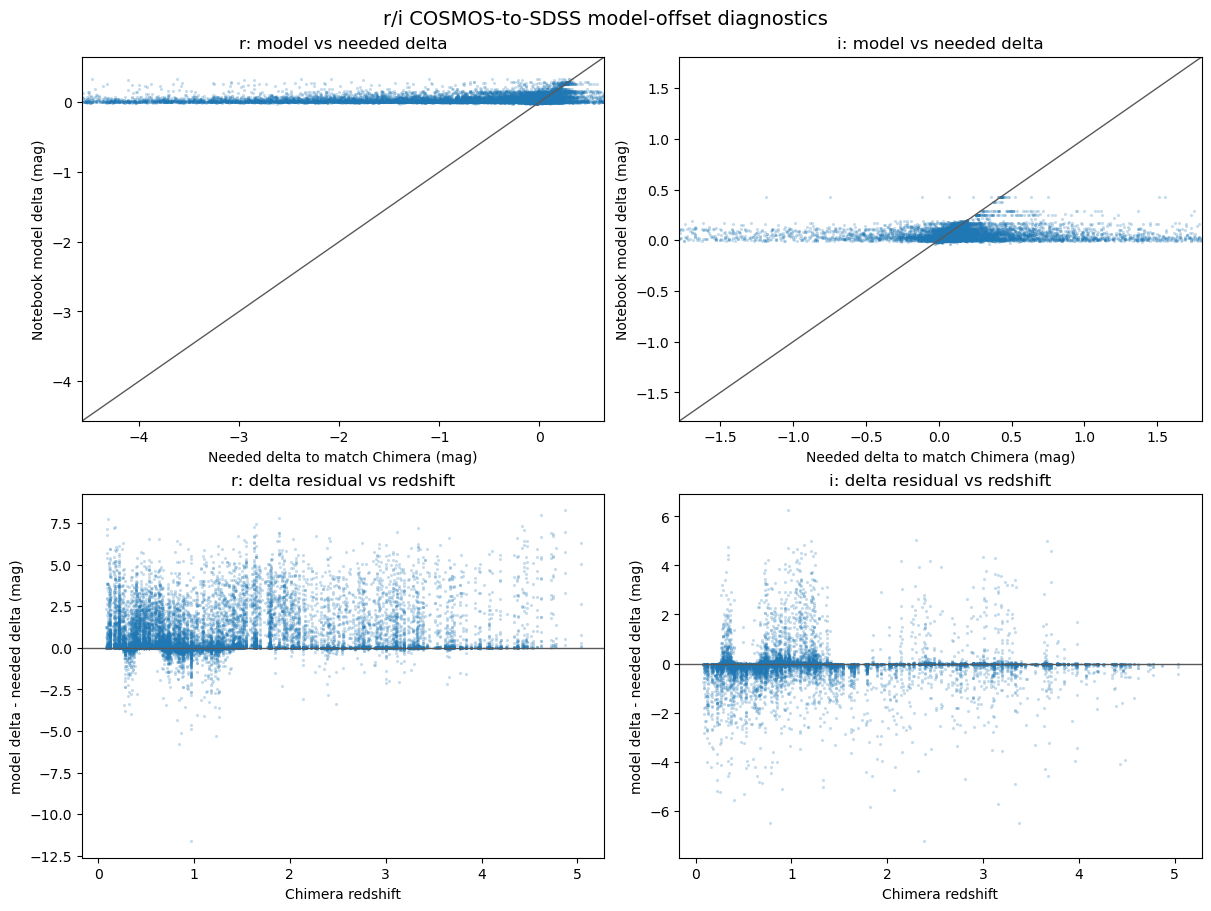

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)

for idx, band in enumerate(["r", "i"]):
    model_delta = np.asarray(ri_model_delta_diagnostics[f"{band}_model_delta_mag"], dtype=float)
    needed_delta = np.asarray(ri_model_delta_diagnostics[f"{band}_needed_delta_mag"], dtype=float)
    residual = np.asarray(ri_model_delta_diagnostics[f"{band}_model_minus_needed_delta_mag"], dtype=float)
    redshift = np.asarray(ri_model_delta_diagnostics["chimera_redshift"], dtype=float)
    valid = np.isfinite(model_delta) & np.isfinite(needed_delta)

    ax = axes[0, idx]
    ax.scatter(needed_delta[valid], model_delta[valid], s=5, alpha=0.25, linewidths=0)
    lo, hi = np.nanpercentile(np.concatenate([needed_delta[valid], model_delta[valid]]), [1, 99]) if np.any(valid) else (-1, 1)
    ax.plot([lo, hi], [lo, hi], color="0.35", linewidth=1)
    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)
    ax.set_xlabel("Needed delta to match Chimera (mag)")
    ax.set_ylabel("Notebook model delta (mag)")
    ax.set_title(f"{band}: model vs needed delta")

    ax = axes[1, idx]
    valid_resid = np.isfinite(residual) & np.isfinite(redshift)
    ax.axhline(0, color="0.35", linewidth=1)
    ax.scatter(redshift[valid_resid], residual[valid_resid], s=5, alpha=0.25, linewidths=0)
    ax.set_xlabel("Chimera redshift")
    ax.set_ylabel("model delta - needed delta (mag)")
    ax.set_title(f"{band}: delta residual vs redshift")

fig.suptitle("r/i COSMOS-to-SDSS model-offset diagnostics", fontsize=14)
fig.savefig(RI_MODEL_DELTA_DIAGNOSTIC_PLOT, dpi=180)
print(f"Wrote r/i model delta diagnostic plot to {RI_MODEL_DELTA_DIAGNOSTIC_PLOT}")
plt.show()


Wrote component residual plot to /home/nicho/GRAHSP/grahspj/notebook_outputs/19_component_residual_diagnostics.png


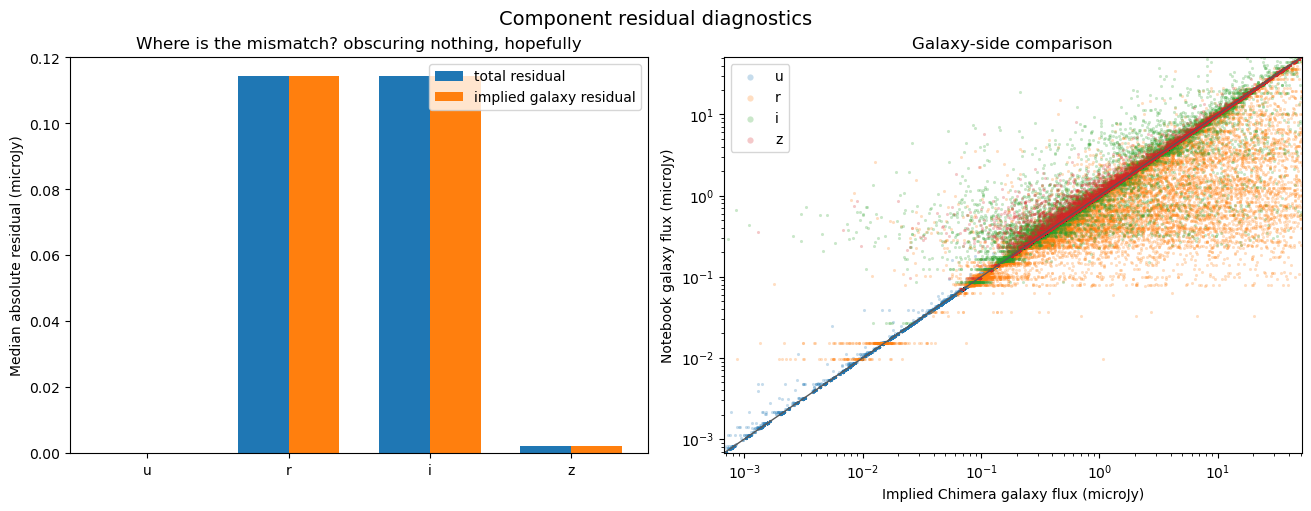

In [33]:
bands = list(BAND_COLUMNS)
median_total = np.array([
    np.nanmedian(np.abs(np.asarray(component_diagnostics[f"{band}_total_residual_microjy"], dtype=float)))
    for band in bands
])
median_galaxy = np.array([
    np.nanmedian(np.abs(np.asarray(component_diagnostics[f"{band}_galaxy_residual_microjy"], dtype=float)))
    for band in bands
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
xpos = np.arange(len(bands))
width = 0.36

axes[0].bar(xpos - width / 2, median_total, width=width, label="total residual")
axes[0].bar(xpos + width / 2, median_galaxy, width=width, label="implied galaxy residual")
axes[0].set_xticks(xpos, bands)
axes[0].set_ylabel("Median absolute residual (microJy)")
axes[0].set_title("Where is the mismatch? obscuring nothing, hopefully")
axes[0].legend()

for band in bands:
    implied = np.asarray(component_diagnostics[f"{band}_implied_chimera_galaxy_flux_microjy"], dtype=float)
    notebook = np.asarray(component_diagnostics[f"{band}_notebook_galaxy_flux_microjy"], dtype=float)
    valid = np.isfinite(implied) & np.isfinite(notebook) & (implied > 0) & (notebook > 0)
    axes[1].scatter(implied[valid], notebook[valid], s=5, alpha=0.25, linewidths=0, label=f"{band}")

all_values = []
for band in bands:
    all_values.append(np.asarray(component_diagnostics[f"{band}_implied_chimera_galaxy_flux_microjy"], dtype=float))
    all_values.append(np.asarray(component_diagnostics[f"{band}_notebook_galaxy_flux_microjy"], dtype=float))
all_values = np.concatenate(all_values)
all_values = all_values[np.isfinite(all_values) & (all_values > 0)]
low, high = np.nanpercentile(all_values, [1, 99]) if len(all_values) else (1e-3, 1.0)
axes[1].plot([low, high], [low, high], color="0.35", linewidth=1)
axes[1].set_xscale("log")
axes[1].set_yscale("log")
axes[1].set_xlim(low, high)
axes[1].set_ylim(low, high)
axes[1].set_xlabel("Implied Chimera galaxy flux (microJy)")
axes[1].set_ylabel("Notebook galaxy flux (microJy)")
axes[1].set_title("Galaxy-side comparison")
axes[1].legend(markerscale=2)

fig.suptitle("Component residual diagnostics", fontsize=14)
fig.savefig(COMPONENT_DIAGNOSTIC_PLOT, dpi=180)
print(f"Wrote component residual plot to {COMPONENT_DIAGNOSTIC_PLOT}")
plt.show()


Updated /home/nicho/GRAHSP/grahspj/notebook_outputs/19_chimera_cosmos_dr7q_photometry_deviations.csv with logLbol_chimera
Wrote deviation summary plot to /home/nicho/GRAHSP/grahspj/notebook_outputs/19_chimera_cosmos_dr7q_deviation_summary.png


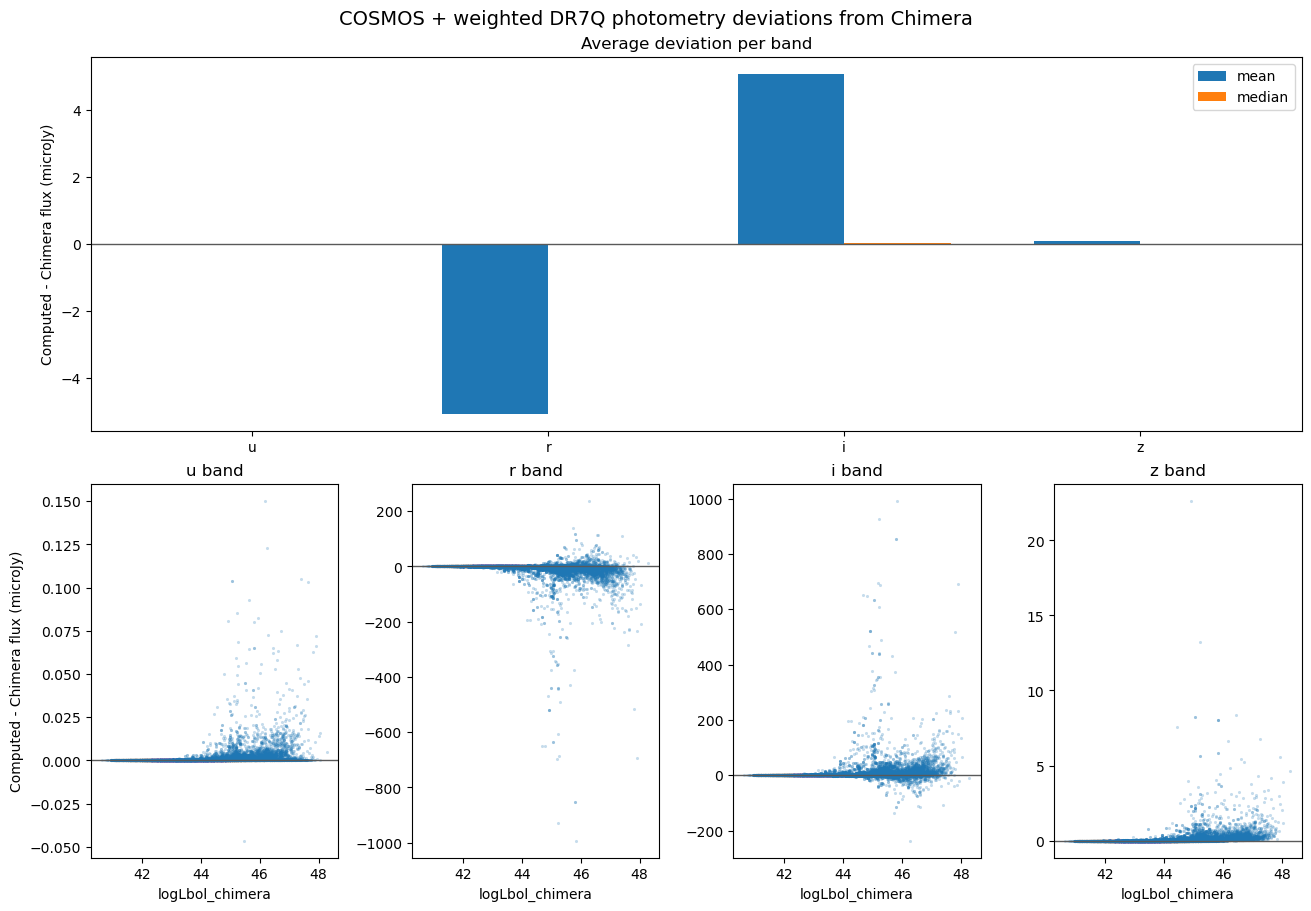

In [34]:
fullinfo_hdul = fits.open(CHIMERA_FULLINFO_FITS, memmap=True)
fullinfo = fullinfo_hdul[1].data

fullinfo_required_columns = {"id", "logLbol_QSO", "chimera_QSO_weight"}
missing_fullinfo_columns = sorted(fullinfo_required_columns - set(fullinfo.names))
if missing_fullinfo_columns:
    raise KeyError(f"Missing Chimera fullinfo columns: {missing_fullinfo_columns}")

fullinfo_index = {text_value(row["id"]): idx for idx, row in enumerate(fullinfo)}
log_lbol_chimera = []

for row in deviations:
    chimera_id = text_value(row["chimera_id"])
    fullinfo_row = fullinfo[fullinfo_index[chimera_id]]
    log_lbol_qso = float(fullinfo_row["logLbol_QSO"])
    qso_weight = float(fullinfo_row["chimera_QSO_weight"])
    if np.isfinite(log_lbol_qso) and qso_weight > 0:
        log_lbol_chimera.append(log_lbol_qso + np.log10(qso_weight))
    else:
        log_lbol_chimera.append(np.nan)

deviations["logLbol_chimera"] = np.array(log_lbol_chimera, dtype=float)
deviations.write(DEVIATIONS_CSV, format="ascii.csv", overwrite=True)
print(f"Updated {DEVIATIONS_CSV} with logLbol_chimera")

bands = list(BAND_COLUMNS)
mean_deviation = np.array([np.nanmean(deviations[f"{band}_deviation_microjy"]) for band in bands])
median_deviation = np.array([np.nanmedian(deviations[f"{band}_deviation_microjy"]) for band in bands])

fig = plt.figure(figsize=(13, 9), constrained_layout=True)
grid = fig.add_gridspec(2, 4)

ax_bar = fig.add_subplot(grid[0, :])
xpos = np.arange(len(bands))
width = 0.36
ax_bar.axhline(0, color="0.35", linewidth=1)
ax_bar.bar(xpos - width / 2, mean_deviation, width=width, label="mean")
ax_bar.bar(xpos + width / 2, median_deviation, width=width, label="median")
ax_bar.set_xticks(xpos, bands)
ax_bar.set_ylabel("Computed - Chimera flux (microJy)")
ax_bar.set_title("Average deviation per band")
ax_bar.legend()

for idx, band in enumerate(bands):
    ax = fig.add_subplot(grid[1, idx])
    luminosity = np.asarray(deviations["logLbol_chimera"], dtype=float)
    band_deviation = np.asarray(deviations[f"{band}_deviation_microjy"], dtype=float)
    valid = np.isfinite(luminosity) & np.isfinite(band_deviation)

    ax.axhline(0, color="0.35", linewidth=1)
    ax.scatter(luminosity[valid], band_deviation[valid], s=5, alpha=0.25, linewidths=0)
    ax.set_title(f"{band} band")
    ax.set_xlabel("logLbol_chimera")
    if idx == 0:
        ax.set_ylabel("Computed - Chimera flux (microJy)")

fig.suptitle("COSMOS + weighted DR7Q photometry deviations from Chimera", fontsize=14)
fig.savefig(DEVIATION_PLOT, dpi=180)

print(f"Wrote deviation summary plot to {DEVIATION_PLOT}")
plt.show()

In [35]:
display_columns = [
    "chimera_id",
    "chimera_qso_weight",
    "u_weighted_flux_microjy",
    "r_weighted_flux_microjy",
    "i_weighted_flux_microjy",
    "z_weighted_flux_microjy",
]

combined[display_columns][:10]

chimera_id,chimera_qso_weight,u_weighted_flux_microjy,r_weighted_flux_microjy,i_weighted_flux_microjy,z_weighted_flux_microjy
str32,float64,float64,float64,float64,float64
151046.20+011819.0_709103_0.001,0.001,0.7338413525620923,4.597103423416529,6.534156291546719,10.810684905999413
153541.18-001621.6_552259_0.003,0.003,0.5344267896350572,3.6216378441631574,9.289782209696146,17.407719320494348
082041.86+170031.9_559961_1,1.0,29.27950899961134,67.78476357331492,92.63840095958636,127.04306654030177
160329.47+533942.9_692003_0.01,0.01,1.9534251793791826,2.8995010102442182,3.765011841170453,5.3269681816149195
142135.11+054850.6_697467_0.03,0.03,4.934999484205653,6.334041252341231,6.745125189704807,8.45340907571278
155241.77+062200.9_701891_0.003,0.003,0.2341553242693669,1.3202526611048995,3.659985642856905,7.13259246580925
154253.09+085032.7_698976_0.0001,0.0001,1.95527017202608,8.00449380803488,9.429885768477885,13.035575526109513
151923.68+232238.0_558576_0.001,0.001,1.5510199802300875,6.084396307709751,7.461639640150995,10.79571647437057
091955.34+552137.1_556116_0.3,0.3,522.8556020980518,462.5142261251776,768.3104263894226,577.7379677622108


## Diagnostic: Low QSO-Weight Objects Only

This repeats the `r/i` model-delta check for objects with very small QSO contribution. If the extreme needed-delta tails are caused by unstable QSO subtraction, they should shrink for low-weight objects.

Low-QSO rows: 6,426 / 18,168
r: median(model-needed)=0.004306 mag, median |model-needed|=0.01269 mag, 16-84%=[-0.00849103  0.05756974]
i: median(model-needed)=-0.00274 mag, median |model-needed|=0.007686 mag, 16-84%=[-0.03636365  0.00448477]
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_low_qso_weight_ri_delta_diagnostics.csv
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_low_qso_weight_ri_delta_diagnostics.png


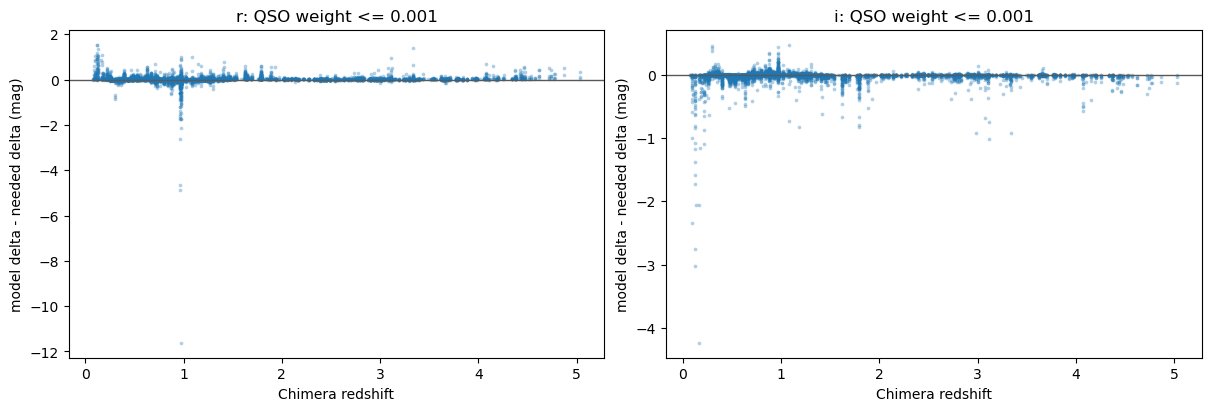

In [36]:
LOW_QSO_DIAGNOSTIC_CSV = PROJECT_ROOT / "notebook_outputs" / "19_low_qso_weight_ri_delta_diagnostics.csv"
LOW_QSO_DIAGNOSTIC_PLOT = PROJECT_ROOT / "notebook_outputs" / "19_low_qso_weight_ri_delta_diagnostics.png"
LOW_QSO_WEIGHT_MAX = 0.001

low_qso_mask = np.asarray(ri_model_delta_diagnostics["chimera_qso_weight"], dtype=float) <= LOW_QSO_WEIGHT_MAX
low_qso_delta_diagnostics = ri_model_delta_diagnostics[low_qso_mask]
low_qso_delta_diagnostics.write(LOW_QSO_DIAGNOSTIC_CSV, format="ascii.csv", overwrite=True)

print(f"Low-QSO rows: {len(low_qso_delta_diagnostics):,} / {len(ri_model_delta_diagnostics):,}")
for band in ["r", "i"]:
    residual = np.asarray(low_qso_delta_diagnostics[f"{band}_model_minus_needed_delta_mag"], dtype=float)
    valid = np.isfinite(residual)
    print(
        f"{band}: median(model-needed)={np.nanmedian(residual):.4g} mag, "
        f"median |model-needed|={np.nanmedian(np.abs(residual)):.4g} mag, "
        f"16-84%={np.nanpercentile(residual[valid], [16, 84]) if np.any(valid) else np.array([np.nan, np.nan])}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for idx, band in enumerate(["r", "i"]):
    redshift = np.asarray(low_qso_delta_diagnostics["chimera_redshift"], dtype=float)
    residual = np.asarray(low_qso_delta_diagnostics[f"{band}_model_minus_needed_delta_mag"], dtype=float)
    valid = np.isfinite(redshift) & np.isfinite(residual)
    axes[idx].axhline(0, color="0.35", linewidth=1)
    axes[idx].scatter(redshift[valid], residual[valid], s=7, alpha=0.35, linewidths=0)
    axes[idx].set_xlabel("Chimera redshift")
    axes[idx].set_ylabel("model delta - needed delta (mag)")
    axes[idx].set_title(f"{band}: QSO weight <= {LOW_QSO_WEIGHT_MAX:g}")
fig.savefig(LOW_QSO_DIAGNOSTIC_PLOT, dpi=180)
print(f"Wrote {LOW_QSO_DIAGNOSTIC_CSV}")
print(f"Wrote {LOW_QSO_DIAGNOSTIC_PLOT}")
plt.show()

## Diagnostic: Strict Positive-Flux Mask

This removes pathological implied-galaxy cases before computing needed deltas. It keeps rows where both the source-preprocessed flux and implied Chimera galaxy flux are positive and where their ratio is not extreme.

Strict-mask rows: 12,801 / 18,168
r: median(model-needed)=0.01435 mag, median |model-needed|=0.05272 mag, 16-84%=[-0.03181527  0.28438958]
i: median(model-needed)=-0.009613 mag, median |model-needed|=0.03115 mag, 16-84%=[-0.22137529  0.01564676]
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_strict_mask_ri_delta_diagnostics.csv
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_strict_mask_ri_delta_diagnostics.png


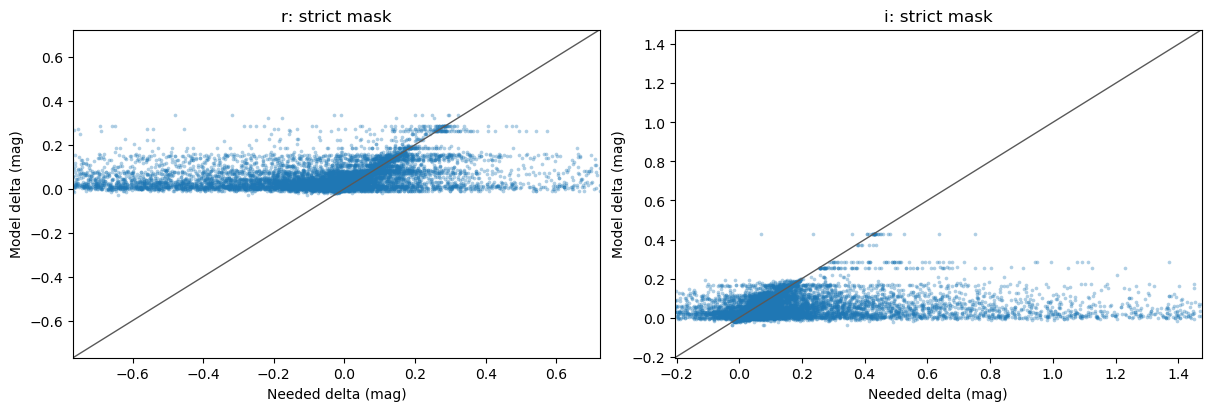

In [37]:
STRICT_MASK_DIAGNOSTIC_CSV = PROJECT_ROOT / "notebook_outputs" / "19_strict_mask_ri_delta_diagnostics.csv"
STRICT_MASK_DIAGNOSTIC_PLOT = PROJECT_ROOT / "notebook_outputs" / "19_strict_mask_ri_delta_diagnostics.png"

strict_masks = {}
for band in ["r", "i"]:
    source = np.asarray(ri_model_delta_diagnostics[f"{band}_source_preprocessed_flux_microjy"], dtype=float)
    implied = np.asarray(ri_model_delta_diagnostics[f"{band}_implied_chimera_galaxy_flux_microjy"], dtype=float)
    ratio = implied / source
    strict_masks[band] = np.isfinite(source) & np.isfinite(implied) & (source > 0) & (implied > 0) & (ratio > 0.1) & (ratio < 10.0)

strict_mask = strict_masks["r"] & strict_masks["i"]
strict_delta_diagnostics = ri_model_delta_diagnostics[strict_mask]
strict_delta_diagnostics.write(STRICT_MASK_DIAGNOSTIC_CSV, format="ascii.csv", overwrite=True)

print(f"Strict-mask rows: {len(strict_delta_diagnostics):,} / {len(ri_model_delta_diagnostics):,}")
for band in ["r", "i"]:
    residual = np.asarray(strict_delta_diagnostics[f"{band}_model_minus_needed_delta_mag"], dtype=float)
    valid = np.isfinite(residual)
    print(
        f"{band}: median(model-needed)={np.nanmedian(residual):.4g} mag, "
        f"median |model-needed|={np.nanmedian(np.abs(residual)):.4g} mag, "
        f"16-84%={np.nanpercentile(residual[valid], [16, 84]) if np.any(valid) else np.array([np.nan, np.nan])}"
    )

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for idx, band in enumerate(["r", "i"]):
    needed = np.asarray(strict_delta_diagnostics[f"{band}_needed_delta_mag"], dtype=float)
    model = np.asarray(strict_delta_diagnostics[f"{band}_model_delta_mag"], dtype=float)
    valid = np.isfinite(needed) & np.isfinite(model)
    axes[idx].scatter(needed[valid], model[valid], s=7, alpha=0.35, linewidths=0)
    lo, hi = np.nanpercentile(np.concatenate([needed[valid], model[valid]]), [1, 99]) if np.any(valid) else (-1, 1)
    axes[idx].plot([lo, hi], [lo, hi], color="0.35", linewidth=1)
    axes[idx].set_xlim(lo, hi)
    axes[idx].set_ylim(lo, hi)
    axes[idx].set_xlabel("Needed delta (mag)")
    axes[idx].set_ylabel("Model delta (mag)")
    axes[idx].set_title(f"{band}: strict mask")
fig.savefig(STRICT_MASK_DIAGNOSTIC_PLOT, dpi=180)
print(f"Wrote {STRICT_MASK_DIAGNOSTIC_CSV}")
print(f"Wrote {STRICT_MASK_DIAGNOSTIC_PLOT}")
plt.show()

## Diagnostic: Residual Versus QSO Weight

This checks whether the remaining `r/i` residuals scale with `chimera_qso_weight`. If they do, the QSO term is still contaminating the component diagnostic even though the bar plot looks galaxy-side.

Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_residual_vs_qso_weight.csv
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_residual_vs_qso_weight.png


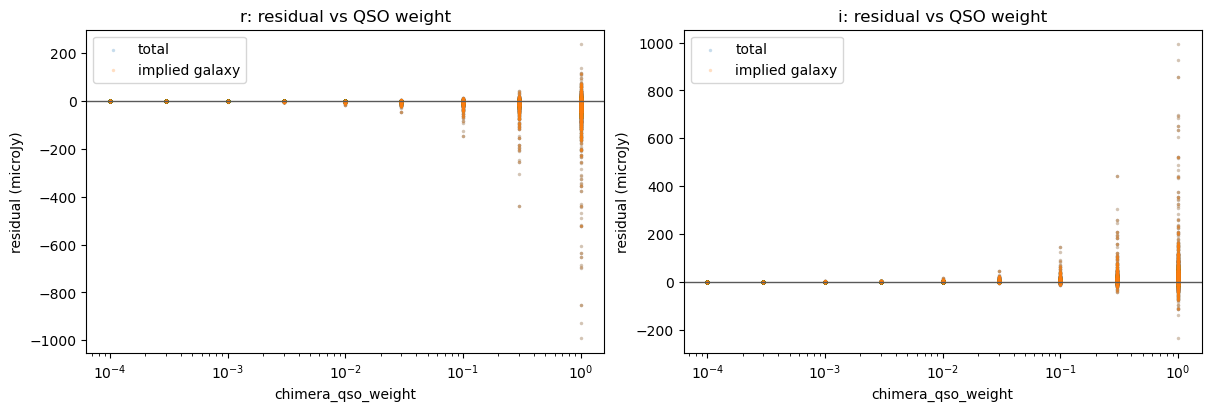

In [38]:
RESIDUAL_VS_QSO_WEIGHT_CSV = PROJECT_ROOT / "notebook_outputs" / "19_residual_vs_qso_weight.csv"
RESIDUAL_VS_QSO_WEIGHT_PLOT = PROJECT_ROOT / "notebook_outputs" / "19_residual_vs_qso_weight.png"

qso_weight_rows = []
for row in component_diagnostics:
    out = {
        "chimera_id": text_value(row["chimera_id"]),
        "cosmos_id": int(row["cosmos_id"]),
        "chimera_qso_weight": float(row["chimera_qso_weight"]),
    }
    for band in ["r", "i"]:
        out[f"{band}_total_residual_microjy"] = float(row[f"{band}_total_residual_microjy"])
        out[f"{band}_galaxy_residual_microjy"] = float(row[f"{band}_galaxy_residual_microjy"])
    qso_weight_rows.append(out)
residual_vs_qso_weight = Table(rows=qso_weight_rows)
residual_vs_qso_weight.write(RESIDUAL_VS_QSO_WEIGHT_CSV, format="ascii.csv", overwrite=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
weights = np.asarray(residual_vs_qso_weight["chimera_qso_weight"], dtype=float)
for idx, band in enumerate(["r", "i"]):
    total = np.asarray(residual_vs_qso_weight[f"{band}_total_residual_microjy"], dtype=float)
    galaxy = np.asarray(residual_vs_qso_weight[f"{band}_galaxy_residual_microjy"], dtype=float)
    valid = np.isfinite(weights) & (weights > 0) & np.isfinite(total) & np.isfinite(galaxy)
    axes[idx].axhline(0, color="0.35", linewidth=1)
    axes[idx].scatter(weights[valid], total[valid], s=6, alpha=0.25, linewidths=0, label="total")
    axes[idx].scatter(weights[valid], galaxy[valid], s=6, alpha=0.25, linewidths=0, label="implied galaxy")
    axes[idx].set_xscale("log")
    axes[idx].set_xlabel("chimera_qso_weight")
    axes[idx].set_ylabel("residual (microJy)")
    axes[idx].set_title(f"{band}: residual vs QSO weight")
    axes[idx].legend()
fig.savefig(RESIDUAL_VS_QSO_WEIGHT_PLOT, dpi=180)
print(f"Wrote {RESIDUAL_VS_QSO_WEIGHT_CSV}")
print(f"Wrote {RESIDUAL_VS_QSO_WEIGHT_PLOT}")
plt.show()

## Diagnostic: Implied Galaxy With Chimera's Exact QSO-Magnitude Convention

This recomputes the implied galaxy flux using `QSO-orig.fits` and the exact optical mapping used by `convert_QSOs.py`: `u <- umag0`, `r <- imag0`, `i <- rmag0`, and `z <- zmag0`. It is only a diagnostic for the subtraction term; it does not alter the main reconstruction.

Missing QSO-orig matches: 0
r: median |model-needed| with exact QSO convention = 9.764e-05 mag
i: median |model-needed| with exact QSO convention = 4.775e-05 mag
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_exact_qso_convention_implied_galaxy.csv
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_exact_qso_convention_implied_galaxy.png


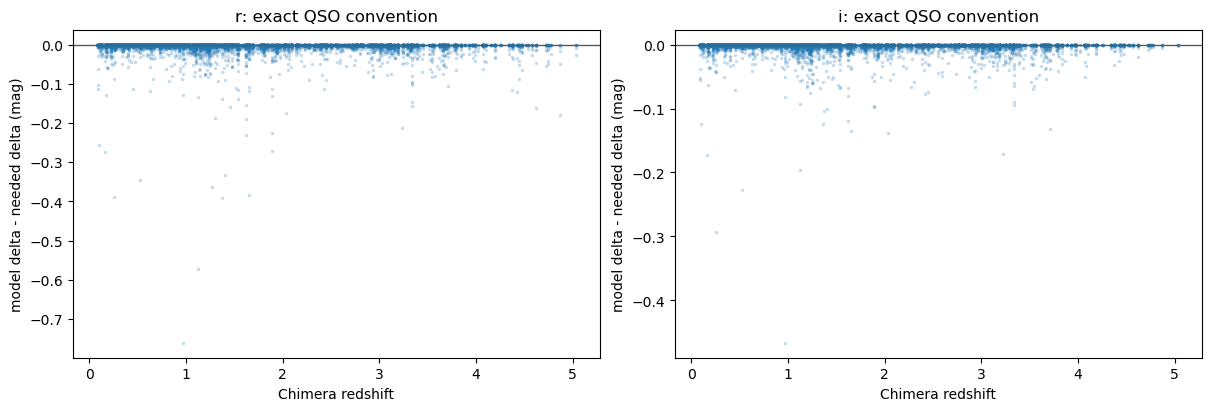

In [39]:
EXACT_QSO_CONVENTION_CSV = PROJECT_ROOT / "notebook_outputs" / "19_exact_qso_convention_implied_galaxy.csv"
EXACT_QSO_CONVENTION_PLOT = PROJECT_ROOT / "notebook_outputs" / "19_exact_qso_convention_implied_galaxy.png"
QSO_ORIG_FITS = PROJECT_ROOT / "data" / "chimeras-2023-10-11" / "QSO-orig.fits"

qso_orig = fits.open(QSO_ORIG_FITS, memmap=True)[1].data
qso_orig_index = {
    (text_value(row["SDSS"]), int(row["Plate"]), int(row["MJD"]), int(row["Fiber"])): idx
    for idx, row in enumerate(qso_orig)
}
chimera_qso_mag_columns = {"r": "imag0", "i": "rmag0"}

exact_qso_rows = []
missing_qso_orig = []
for prov, combined_row in zip(provenance_rows, combined):
    chimera_id = text_value(combined_row["chimera_id"])
    key = (prov["dr7q_name"].strip(), int(prov["dr7q_plate"]), int(prov["dr7q_mjd"]), int(prov["dr7q_fiber"]))
    qso_idx = qso_orig_index.get(key)
    if qso_idx is None:
        missing_qso_orig.append(key)
    weight = float(combined_row["chimera_qso_weight"])
    chimera_row = chimera_phot[chimera_index[chimera_id]]
    out = {
        "chimera_id": chimera_id,
        "cosmos_id": int(combined_row["cosmos_id"]),
        "chimera_qso_weight": weight,
        "chimera_redshift": float(combined_row["chimera_redshift"]),
    }
    for band in ["r", "i"]:
        source_flux = float(combined_row[f"{band}_cosmos_flux_source_preprocessed_microjy"])
        chimera_flux = float(chimera_row[f"{band}_sdss"]) * 1_000.0
        exact_qso_flux = ab_mag_to_microjy(qso_orig[qso_idx][chimera_qso_mag_columns[band]]) if qso_idx is not None else np.nan
        implied_flux = chimera_flux - weight * exact_qso_flux
        needed_delta = microjy_to_ab_mag(implied_flux) - microjy_to_ab_mag(source_flux)
        model_delta = float(combined_row[f"{band}_cosmos_to_sdss_model_mag_delta"])
        out[f"{band}_exact_qso_flux_microjy"] = exact_qso_flux
        out[f"{band}_implied_galaxy_exact_qso_microjy"] = implied_flux
        out[f"{band}_needed_delta_exact_qso_mag"] = needed_delta
        out[f"{band}_model_minus_needed_exact_qso_mag"] = model_delta - needed_delta
    exact_qso_rows.append(out)

exact_qso_convention_diagnostic = Table(rows=exact_qso_rows)
exact_qso_convention_diagnostic.write(EXACT_QSO_CONVENTION_CSV, format="ascii.csv", overwrite=True)
print(f"Missing QSO-orig matches: {len(missing_qso_orig):,}")
for band in ["r", "i"]:
    residual = np.asarray(exact_qso_convention_diagnostic[f"{band}_model_minus_needed_exact_qso_mag"], dtype=float)
    print(f"{band}: median |model-needed| with exact QSO convention = {np.nanmedian(np.abs(residual)):.4g} mag")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
for idx, band in enumerate(["r", "i"]):
    redshift = np.asarray(exact_qso_convention_diagnostic["chimera_redshift"], dtype=float)
    residual = np.asarray(exact_qso_convention_diagnostic[f"{band}_model_minus_needed_exact_qso_mag"], dtype=float)
    valid = np.isfinite(redshift) & np.isfinite(residual)
    axes[idx].axhline(0, color="0.35", linewidth=1)
    axes[idx].scatter(redshift[valid], residual[valid], s=6, alpha=0.25, linewidths=0)
    axes[idx].set_xlabel("Chimera redshift")
    axes[idx].set_ylabel("model delta - needed delta (mag)")
    axes[idx].set_title(f"{band}: exact QSO convention")
fig.savefig(EXACT_QSO_CONVENTION_PLOT, dpi=180)
print(f"Wrote {EXACT_QSO_CONVENTION_CSV}")
print(f"Wrote {EXACT_QSO_CONVENTION_PLOT}")
plt.show()

## Diagnostic: Source Flux / Implied Galaxy Flux Ratios

This plots the ratio of notebook source-preprocessed flux to implied Chimera galaxy flux versus QSO weight and redshift. It is meant to expose whether the extreme deltas are driven by faint or unstable implied galaxy fluxes.

Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_source_implied_flux_ratios.csv
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_source_implied_flux_ratios.png


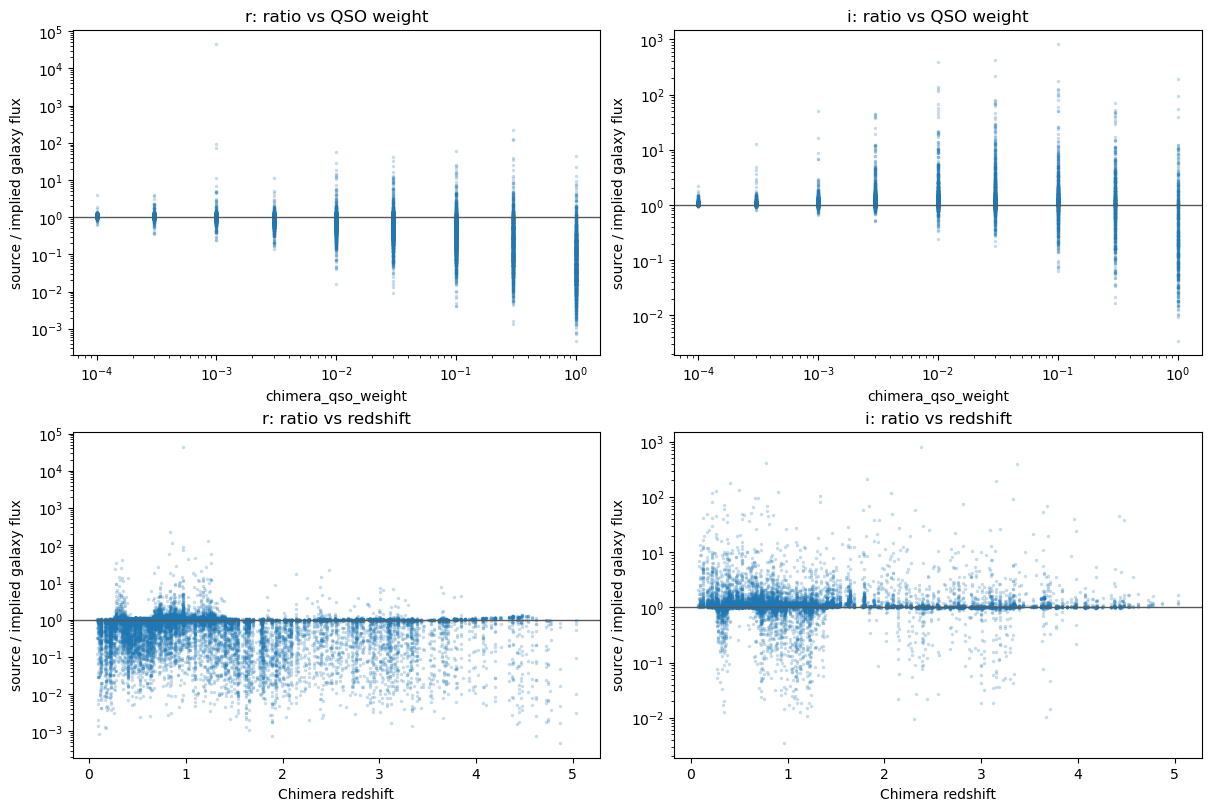

In [40]:
SOURCE_IMPLIED_RATIO_CSV = PROJECT_ROOT / "notebook_outputs" / "19_source_implied_flux_ratios.csv"
SOURCE_IMPLIED_RATIO_PLOT = PROJECT_ROOT / "notebook_outputs" / "19_source_implied_flux_ratios.png"

ratio_rows = []
for row in ri_model_delta_diagnostics:
    out = {
        "chimera_id": text_value(row["chimera_id"]),
        "cosmos_id": int(row["cosmos_id"]),
        "chimera_qso_weight": float(row["chimera_qso_weight"]),
        "chimera_redshift": float(row["chimera_redshift"]),
    }
    for band in ["r", "i"]:
        source = float(row[f"{band}_source_preprocessed_flux_microjy"])
        implied = float(row[f"{band}_implied_chimera_galaxy_flux_microjy"])
        out[f"{band}_source_over_implied"] = source / implied if np.isfinite(source) and np.isfinite(implied) and implied != 0 else np.nan
        out[f"{band}_implied_over_source"] = implied / source if np.isfinite(source) and np.isfinite(implied) and source != 0 else np.nan
    ratio_rows.append(out)
source_implied_ratios = Table(rows=ratio_rows)
source_implied_ratios.write(SOURCE_IMPLIED_RATIO_CSV, format="ascii.csv", overwrite=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)
weights = np.asarray(source_implied_ratios["chimera_qso_weight"], dtype=float)
redshift = np.asarray(source_implied_ratios["chimera_redshift"], dtype=float)
for idx, band in enumerate(["r", "i"]):
    ratio = np.asarray(source_implied_ratios[f"{band}_source_over_implied"], dtype=float)
    valid_w = np.isfinite(weights) & (weights > 0) & np.isfinite(ratio) & (ratio > 0)
    valid_z = np.isfinite(redshift) & np.isfinite(ratio) & (ratio > 0)
    axes[0, idx].axhline(1, color="0.35", linewidth=1)
    axes[0, idx].scatter(weights[valid_w], ratio[valid_w], s=6, alpha=0.25, linewidths=0)
    axes[0, idx].set_xscale("log")
    axes[0, idx].set_yscale("log")
    axes[0, idx].set_xlabel("chimera_qso_weight")
    axes[0, idx].set_ylabel("source / implied galaxy flux")
    axes[0, idx].set_title(f"{band}: ratio vs QSO weight")
    axes[1, idx].axhline(1, color="0.35", linewidth=1)
    axes[1, idx].scatter(redshift[valid_z], ratio[valid_z], s=6, alpha=0.25, linewidths=0)
    axes[1, idx].set_yscale("log")
    axes[1, idx].set_xlabel("Chimera redshift")
    axes[1, idx].set_ylabel("source / implied galaxy flux")
    axes[1, idx].set_title(f"{band}: ratio vs redshift")
fig.savefig(SOURCE_IMPLIED_RATIO_PLOT, dpi=180)
print(f"Wrote {SOURCE_IMPLIED_RATIO_CSV}")
print(f"Wrote {SOURCE_IMPLIED_RATIO_PLOT}")
plt.show()

## Test: reproduce the Chimera r/i QSO convention

This cell leaves the main reconstruction untouched and tests the suspected fix separately. It recomputes the hybrid photometry using the exact optical QSO magnitude convention seen in `convert_QSOs.py`: `u <- umag0`, `r <- imag0`, `i <- rmag0`, and `z <- zmag0`. The galaxy side still comes from the notebook reconstruction, so this is testing only whether the QSO-side convention explains the remaining `r/i` deviations.

u: median |deviation| = 1.844e-05 microJy; median fractional deviation = 4.472e-05
r: median |deviation| = 6.212e-05 microJy; median fractional deviation = 3.551e-05
i: median |deviation| = 5.111e-05 microJy; median fractional deviation = 2.516e-05
z: median |deviation| = 7.362e-05 microJy; median fractional deviation = 2.455e-05
Missing QSO-orig matches: 0
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_exact_qso_convention_solution_deviations.csv
Wrote /home/nicho/GRAHSP/grahspj/notebook_outputs/19_exact_qso_convention_solution_deviations.png


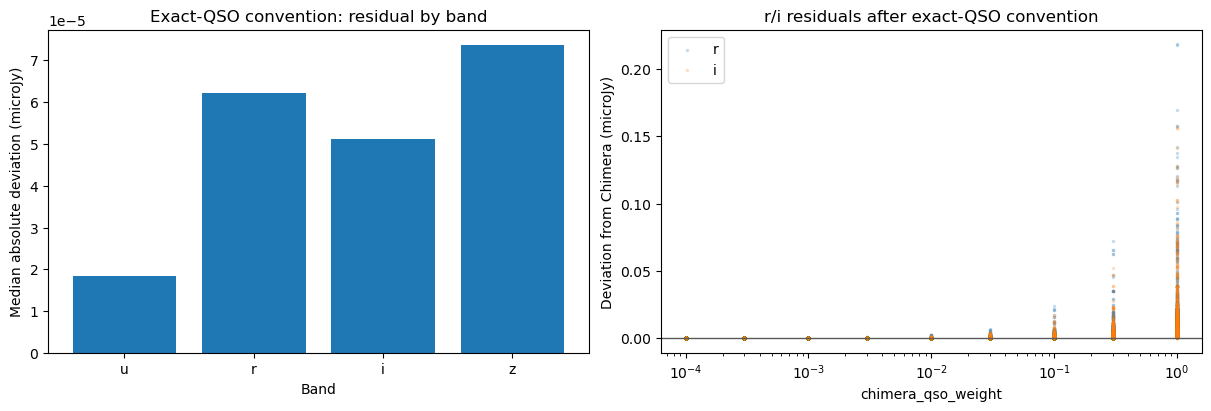

In [41]:
EXACT_QSO_SOLUTION_CSV = PROJECT_ROOT / "notebook_outputs" / "19_exact_qso_convention_solution_deviations.csv"
EXACT_QSO_SOLUTION_PLOT = PROJECT_ROOT / "notebook_outputs" / "19_exact_qso_convention_solution_deviations.png"
QSO_ORIG_FITS = PROJECT_ROOT / "data" / "chimeras-2023-10-11" / "QSO-orig.fits"

qso_orig = fits.open(QSO_ORIG_FITS, memmap=True)[1].data
qso_orig_index = {
    (text_value(row["SDSS"]), int(row["Plate"]), int(row["MJD"]), int(row["Fiber"])): idx
    for idx, row in enumerate(qso_orig)
}
chimera_qso_mag_columns = {"u": "umag0", "r": "imag0", "i": "rmag0", "z": "zmag0"}

solution_rows = []
missing_qso_orig = []
for prov, row in zip(provenance_rows, combined):
    chimera_id = text_value(row["chimera_id"])
    key = (prov["dr7q_name"].strip(), int(prov["dr7q_plate"]), int(prov["dr7q_mjd"]), int(prov["dr7q_fiber"]))
    qso_idx = qso_orig_index.get(key)
    if qso_idx is None:
        missing_qso_orig.append(key)
    chimera_row = chimera_phot[chimera_index[chimera_id]]
    weight = float(row["chimera_qso_weight"])
    out = {
        "chimera_id": chimera_id,
        "cosmos_id": int(row["cosmos_id"]),
        "dr7q_name": text_value(row["dr7q_name"]),
        "chimera_qso_weight": weight,
        "chimera_redshift": float(row["chimera_redshift"]),
    }

    for band in BAND_COLUMNS:
        galaxy_flux = float(row[f"{band}_cosmos_flux_final_microjy"])
        qso_flux = ab_mag_to_microjy(qso_orig[qso_idx][chimera_qso_mag_columns[band]]) if qso_idx is not None else np.nan
        computed_flux = galaxy_flux + weight * qso_flux
        chimera_flux = float(chimera_row[f"{band}_sdss"]) * 1_000.0
        deviation = computed_flux - chimera_flux
        fractional_deviation = deviation / chimera_flux if np.isfinite(chimera_flux) and chimera_flux != 0 else np.nan

        out[f"{band}_galaxy_flux_microjy"] = galaxy_flux
        out[f"{band}_exact_qso_flux_microjy"] = qso_flux
        out[f"{band}_computed_flux_microjy"] = computed_flux
        out[f"{band}_chimera_flux_microjy"] = chimera_flux
        out[f"{band}_deviation_microjy"] = deviation
        out[f"{band}_fractional_deviation"] = fractional_deviation
    solution_rows.append(out)

exact_qso_solution_deviations = Table(rows=solution_rows)
exact_qso_solution_deviations.write(EXACT_QSO_SOLUTION_CSV, format="ascii.csv", overwrite=True)

bands = list(BAND_COLUMNS)
median_abs_deviation = []
median_fractional_deviation = []
for band in bands:
    abs_dev = np.abs(np.asarray(exact_qso_solution_deviations[f"{band}_deviation_microjy"], dtype=float))
    frac_dev = np.asarray(exact_qso_solution_deviations[f"{band}_fractional_deviation"], dtype=float)
    median_abs_deviation.append(np.nanmedian(abs_dev))
    median_fractional_deviation.append(np.nanmedian(frac_dev))
    print(f"{band}: median |deviation| = {median_abs_deviation[-1]:.4g} microJy; median fractional deviation = {median_fractional_deviation[-1]:.4g}")
print(f"Missing QSO-orig matches: {len(missing_qso_orig):,}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
axes[0].bar(bands, median_abs_deviation)
axes[0].set_xlabel("Band")
axes[0].set_ylabel("Median absolute deviation (microJy)")
axes[0].set_title("Exact-QSO convention: residual by band")

weights = np.asarray(exact_qso_solution_deviations["chimera_qso_weight"], dtype=float)
for band in ["r", "i"]:
    deviation = np.asarray(exact_qso_solution_deviations[f"{band}_deviation_microjy"], dtype=float)
    valid = np.isfinite(weights) & (weights > 0) & np.isfinite(deviation)
    axes[1].scatter(weights[valid], deviation[valid], s=6, alpha=0.25, linewidths=0, label=band)
axes[1].axhline(0, color="0.35", linewidth=1)
axes[1].set_xscale("log")
axes[1].set_xlabel("chimera_qso_weight")
axes[1].set_ylabel("Deviation from Chimera (microJy)")
axes[1].set_title("r/i residuals after exact-QSO convention")
axes[1].legend()

fig.savefig(EXACT_QSO_SOLUTION_PLOT, dpi=180)
print(f"Wrote {EXACT_QSO_SOLUTION_CSV}")
print(f"Wrote {EXACT_QSO_SOLUTION_PLOT}")
plt.show()